In [1]:
#Importing pandas library
import pandas as pd

#Creating the dataframe of the Crop Recommendation Data Set
df = pd.read_csv('Crop_recommendation_cleaned.csv')

#Showing the upper 5 data in the dataframe
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41.0,21.770462,80.319644,7.038096,213.841241,rice
2,60,55,44.0,23.004459,82.320763,7.840207,213.841241,rice
3,74,35,40.0,26.491096,80.158363,6.980401,213.841241,rice
4,78,42,42.0,20.130175,81.604873,7.628473,213.841241,rice


First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 15

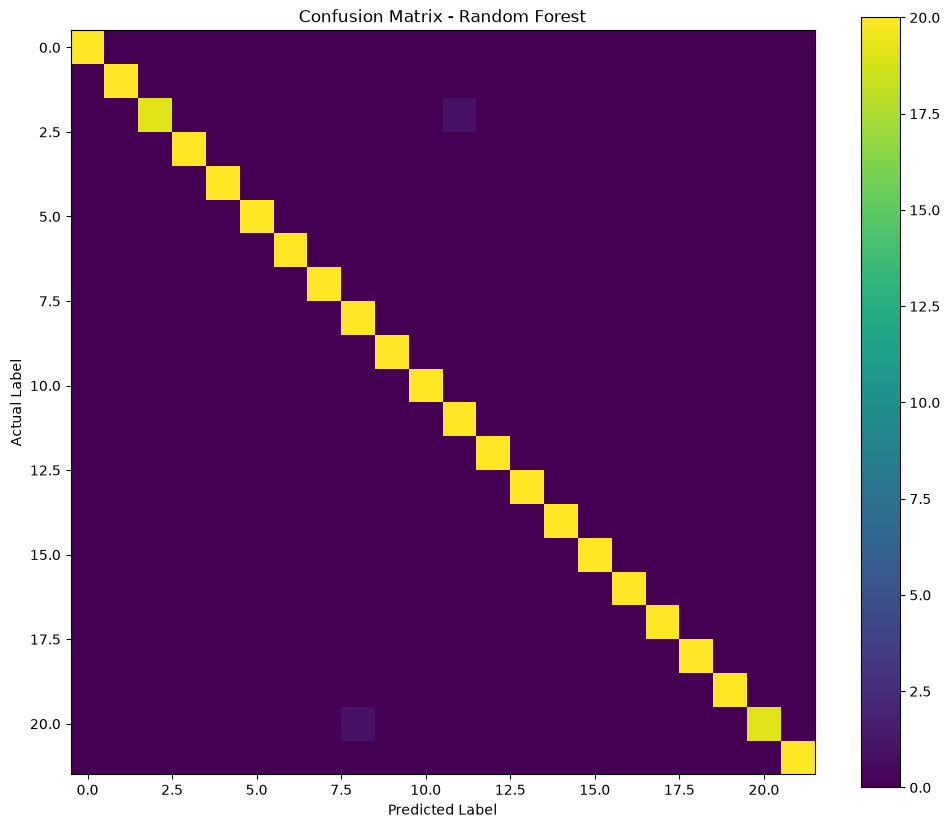


Feature Importance:
rainfall       0.230184
humidity       0.224227
K              0.175393
P              0.150850
N              0.096363
temperature    0.072375
ph             0.050608
dtype: float64


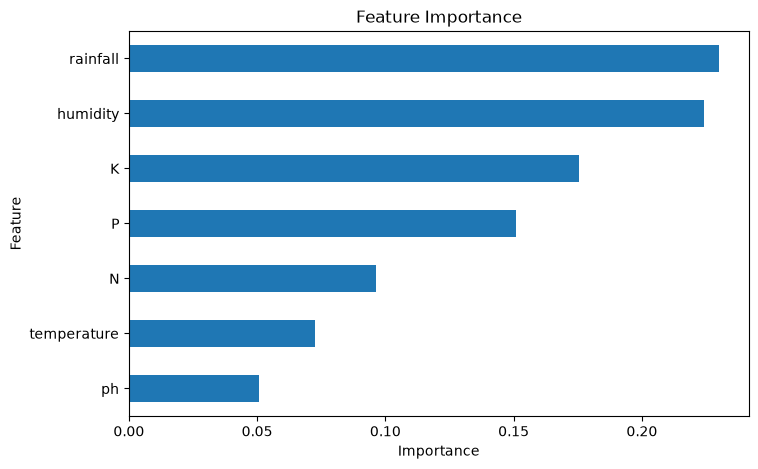


NEW PREDICTION
Recommended Crop: rice


In [2]:
# ============================================
# WEEK 3: DATA MODELLING
# Crop Recommendation - Classification

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("Crop_recommendation.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)


# Features used to predict the crop
X = df.drop("label", axis=1)

# Target variable
y = df["label"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# ============================================
# 5. Create the Random Forest model
# ============================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("\nModel training completed.")

print("\nFirst 10 predicted values:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)


accuracy = accuracy_score(y_test, y_pred)

print("MODEL PERFORMANCE")

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# 8. Classification Report


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Confusion Matrix
 
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(12, 10))

plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

plt.show()

# ============================================
# 10. Feature Importance
# ============================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# Visualise feature importance
plt.figure(figsize=(8, 5))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# ============================================
# 11. Test the model with new data
# ============================================

new_data = pd.DataFrame({
    "N": [90],
    "P": [42],
    "K": [43],
    "temperature": [20.8],
    "humidity": [82],
    "ph": [6.5],
    "rainfall": [202]
})

prediction = model.predict(new_data)

print("NEW PREDICTION")


print("Recommended Crop:", prediction[0])